<a href="https://colab.research.google.com/github/serey-roth/street-sidewalk-segmentation/blob/main/Dual_Pipeline_Analysis_for_Pedestrian_Sidewalk_Safety_with_DeepLabV3_Segmentation_and_Qwen2_5_VL_Safety_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dual-Pipeline Analysis for Pedestrian Sidewalk Safety with DeepLabV3 Segmentation and Qwen2.5-VL Safety Assessment

## Overview

Pre-trained segmentation models, such as DeepLabV3+, are effective at classifying pixel-level details, but are limited to categories in their original training data. Fine-tuning the models to recognize new categories is a possible solution, though it requires annotated training labels for the target images. Vision-Language Models (VLMs) are effective at identifying "what's in an image" through natural-language processing, but are limited due to a lack of spatial reasoning.

This project combines those two approaches into an analysis pipeline for pedestrian sidewalk safety. First, we run pre-trained semantic segmentation with DeepLabV3+ and then perform VLM-based safety assessment with Qwen2.5-VL models. The goal is to evaluate how accurately general-purpose VLMs examine pedestrian sidewalk quality and to what extent they can complement segmentation models in fine-grained scene understanding.

For our analysis, we use HuggingFace's `segments/sidewalk-semantic` [dataset](https://huggingface.co/datasets/segments/sidewalk-semantic), which consists of street-level pedestrian sidewalk images from Belgium in the summer of 2021. For our models, we use `DeepLabV3-ResNet50` for semantic segmentation and `Qwen2.5-VL-3B-Instruct` and `Qwen2.5-VL-7B-Instruct` for VLM assessment.

In [1]:
!pip install datasets

In [2]:
import os
from google.colab import userdata

os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

from datasets import load_dataset

# A dataset of sidewalk images gathered from Belgium in the summer of 2021.
ds = load_dataset("segments/sidewalk-semantic")

README.md:   0%|          | 0.00/4.26k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/635 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  324MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [3]:
# These categories are given to us from the image label -> ground-truth
SEMANTIC_SIDEWALK_CATEGORIES = {
    0: "unlabeled",
    1: "flat-road",
    2: "flat-sidewalk",
    3: "flat-crosswalk",
    4: "flat-cyclinglane",
    5: "flat-parkingdriveway",
    6: "flat-railtrack",
    7: "flat-curb",
    8: "human-person",
    9: "human-rider",
    10: "vehicle-car",
    11: "vehicle-truck",
    12: "vehicle-bus",
    13: "vehicle-tramtrain",
    14: "vehicle-motorcycle",
    15: "vehicle-bicycle",
    16: "vehicle-caravan",
    17: "vehicle-cartrailer",
    18: "construction-building",
    19: "construction-door",
    20: "construction-wall",
    21: "construction-fenceguardrail",
    22: "construction-bridge",
    23: "construction-tunnel",
    24: "construction-stairs",
    25: "object-pole",
    26: "object-trafficsign",
    27: "object-trafficlight",
    28: "nature-vegetation",
    29: "nature-terrain",
    30: "sky",
    31: "void-ground",
    32: "void-dynamic",
    33: "void-static",
    34: "void-unclear",
}

In [4]:
import pprint

print(ds)
print(ds["train"].features)

samples = ds["train"][:3]
images = samples['pixel_values']
labels = samples['label']
pprint.pprint(images[0])
pprint.pprint(labels[0])

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 1000
    })
})
{'pixel_values': Image(mode=None, decode=True), 'label': Image(mode=None, decode=True)}
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1920x1080 at 0x7BE8AE591520>
<PIL.PngImagePlugin.PngImageFile image mode=L size=1920x1080 at 0x7BE8902918E0>


In [5]:
import numpy as np
import pprint

for image, label, index in zip(images, labels, range(0, len(images))):
  print(f"Sample {index + 1}:")

  image_array = np.array(image)
  print("Image shape:", image_array.shape)

  label_array = np.array(label)
  print("Label shape:", label_array.shape)

  unique_classes = np.unique(label_array)
  print("Number of unique classes:", len(unique_classes))
  print("Unique classes in this label:", unique_classes)

  pprint.pprint([SEMANTIC_SIDEWALK_CATEGORIES[index] for index in unique_classes])

  print("\n")

Sample 1:
Image shape: (1080, 1920, 3)
Label shape: (1080, 1920)
Number of unique classes: 15
Unique classes in this label: [ 1  2  3  5  7 10 18 19 20 24 25 26 28 32 33]
['flat-road',
 'flat-sidewalk',
 'flat-crosswalk',
 'flat-parkingdriveway',
 'flat-curb',
 'vehicle-car',
 'construction-building',
 'construction-door',
 'construction-wall',
 'construction-stairs',
 'object-pole',
 'object-trafficsign',
 'nature-vegetation',
 'void-dynamic',
 'void-static']


Sample 2:
Image shape: (1080, 1920, 3)
Label shape: (1080, 1920)
Number of unique classes: 7
Unique classes in this label: [ 1  2  3  7 18 25 28]
['flat-road',
 'flat-sidewalk',
 'flat-crosswalk',
 'flat-curb',
 'construction-building',
 'object-pole',
 'nature-vegetation']


Sample 3:
Image shape: (1080, 1920, 3)
Label shape: (1080, 1920)
Number of unique classes: 9
Unique classes in this label: [ 0  1  2  7 10 18 20 28 33]
['unlabeled',
 'flat-road',
 'flat-sidewalk',
 'flat-curb',
 'vehicle-car',
 'construction-building',
 '

In [6]:
def color_label_image(label_array):
  # Create 3-d array to hold color info
  height, width = label_array.shape

  # Create a blank base image for the label (0, 0, 0) for every pixel
  colored = np.zeros((height, width, 3), dtype=np.uint8)

  for class_id in unique_classes:
    # Each class id at a time, get the color
    color = np.array(colors(class_id)[:3]) * 255

    # Find pixels in the label that have this exact class
    # and replace them with the actual RGB color -> 3d array
    colored[label_array == class_id] = color

  return colored

/tmp/ipykernel_935/4041062767.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(name="rainbow", lut=num_classes)


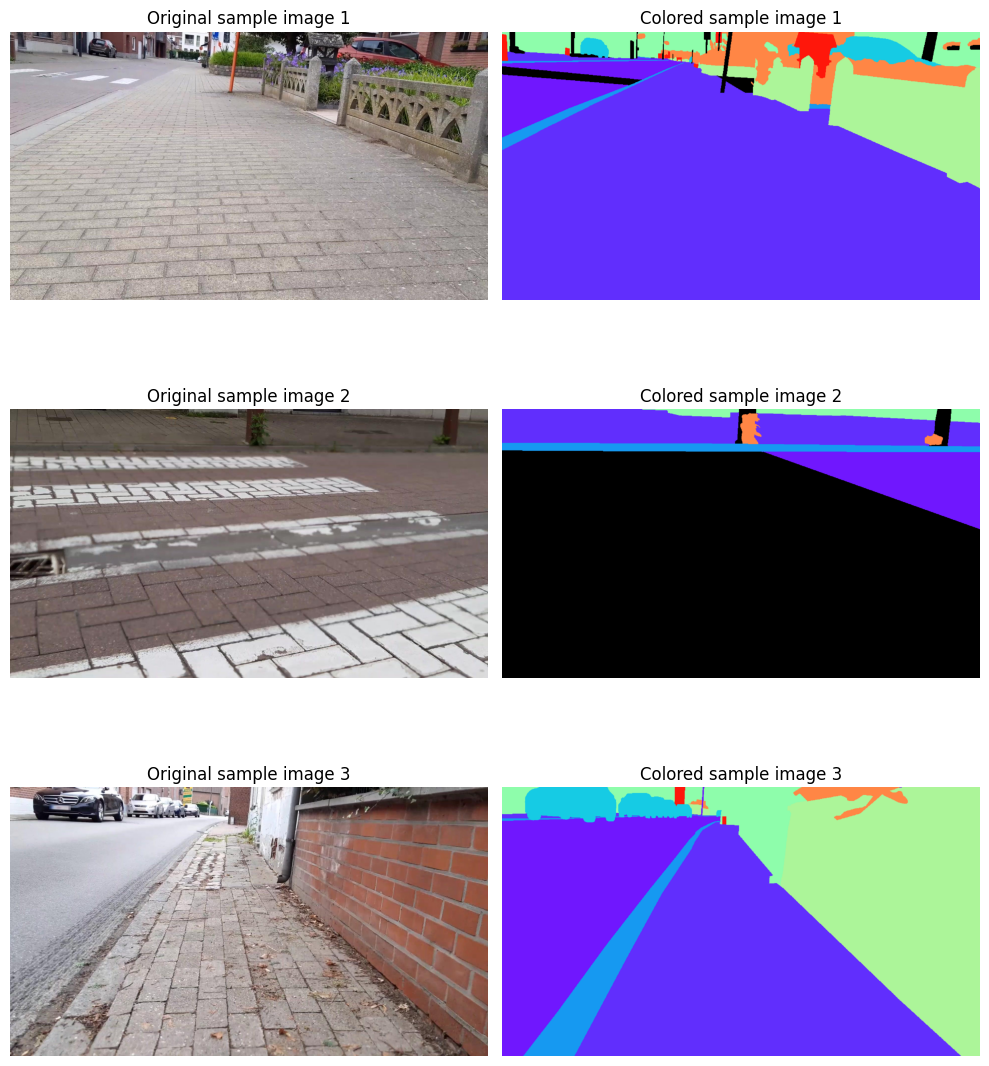

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

num_classes = len(SEMANTIC_SIDEWALK_CATEGORIES)
colors = cm.get_cmap(name="rainbow", lut=num_classes)

figure, axes = plt.subplots(nrows=len(images), ncols=2, figsize=(10, 12))

for image, label, index in zip(images, labels, range(0, len(images))):
  axes[index, 0].imshow(np.array(image))
  axes[index, 0].set_title(f"Original sample image {index + 1}")
  axes[index, 0].set_axis_off()

  axes[index, 1].imshow(color_label_image(np.array(label)))
  axes[index, 1].set_title(f"Colored sample image {index + 1}")
  axes[index, 1].set_axis_off()

plt.tight_layout()
plt.show()


## Semantic Segmentation with DeepLabV3

In [8]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))

CUDA available: True
Device count: 1
Device name: Tesla T4


In [9]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import torch.nn.functional as F

# Load pretrained DeepLabV3 model
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:02<00:00, 79.5MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

DeepLabV3 was trained on COCO/Pascal VOC's 20 general object categories. [source](https://learnopencv.com/deeplabv3-ultimate-guide/)

In [10]:
PASCAL_VOC_CATEGORIES = {
  0: "background",
  1: "aeroplane",
  2: "bicycle",
  3: "bird",
  4: "boat",
  5: "bottle",
  6: "bus",
  7: "car",
  8: "cat",
  9: "chair",
  10: "cow",
  11: "diningtable",
  12: "dog",
  13: "horse",
  14: "motorbike",
  15: "person",
  16: "pottedplant",
  17: "sheep",
  18: "sofa",
  19: "train",
  20: "tvmonitor",
}

In [11]:
images = samples['pixel_values']
labels = samples['label']

In [12]:
# Get the transforms for the pretrained model to transform our image
preprocess = weights.transforms()

# Prepare image
# normalize image to match training conditions
image_tensors = [preprocess(image) for image in images]

# add batch dimension (of shape (N, 3, H, W), where N is the number of images, H and W are expected to be at least 224 pixels.)
image_tensors = [tensor.unsqueeze(0) for tensor in image_tensors]

# match the model device
image_tensors = [tensor.to(device) for tensor in image_tensors]

In [13]:
# Run inference
with torch.no_grad():
  outputs = [model(tensor)["out"][0] for tensor in image_tensors]


In [14]:
# [21, H, W] At each location, unnormalized predictions for every class
# DeepLabV3 was trained on 21 classes, H and W are the transformed dimensions of our image
# At each pixel, is 21-length array of confidence scores for the classes
print(outputs[0].shape)

# Convert model output into predicted class per pixel
# For each pixel, picks the highest confidence score to be the predicted class
pred_labels = [torch.argmax(F.softmax(output, dim=0), dim=0).cpu().numpy() for output in outputs]
print("Predicted classes:", pred_labels[0])

print("Unique predicted classes present:", np.unique(pred_labels[0]))

torch.Size([21, 520, 924])
Predicted classes: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Unique predicted classes present: [0 7]


So DeepLabV3 was only able to classify the car and the background in the first image, and none of the sidewalk-related classes as listed in the label e.g `flat-curb`, `flat-road`, `flat-parkingdriveway`, `nature-vegetation`, etc.

In [15]:
import base64
from io import BytesIO
from IPython.display import HTML, display
from PIL import Image

def image_to_base64_html(img, size=(150, 150)):
    # Ensure img is a PIL Image object
    if isinstance(img, np.ndarray):
        img_pil = Image.fromarray(img)
    else:
        img_pil = img

    img_thumb = img_pil.copy()
    img_thumb.thumbnail(size)
    buffer = BytesIO()
    img_thumb.save(buffer, format="PNG")
    img_str = base64.b64encode(buffer.getvalue()).decode()
    return f'<img src="data:image/png;base64,{img_str}"/>'

,image,label,prediction,labelled_classes,predicted_classes
0,,,,"[flat-road, flat-sidewalk, flat-crosswalk, flat-parkingdriveway, flat-curb, vehicle-car, construction-building, construction-door, construction-wall, construction-stairs, object-pole, object-trafficsign, nature-vegetation, void-dynamic, void-static]","[background, car]"
1,,,,"[flat-road, flat-sidewalk, flat-crosswalk, flat-curb, construction-building, object-pole, nature-vegetation]",[background]
2,,,,"[unlabeled, flat-road, flat-sidewalk, flat-curb, vehicle-car, construction-building, construction-wall, nature-vegetation, void-static]","[background, car]"

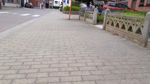
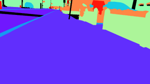
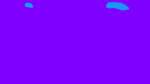
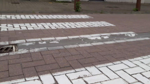
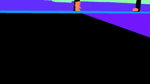
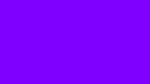
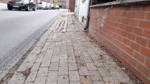
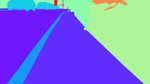
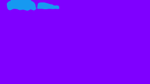

In [16]:
import pandas as pd

results = []

for image, label, pred_label in zip(images, labels, pred_labels):
  seg_classes_label = [SEMANTIC_SIDEWALK_CATEGORIES[class_id] for class_id in list(np.unique(np.array(label)))]
  seg_classes_pred = [PASCAL_VOC_CATEGORIES[class_id] for class_id in list(np.unique(np.array(pred_label)))]

  results.append({
    "image": image_to_base64_html(image),
    "label": image_to_base64_html(color_label_image(np.array(label))),
    "prediction": image_to_base64_html(color_label_image(np.array(pred_label))),
    "labelled_classes": seg_classes_label,
    "predicted_classes": seg_classes_pred,
  })

df = pd.DataFrame(results)

display(HTML(df.to_html(escape=False)))

This is the case with a generic pre-trained segmentation model like DeepLabV3; it can only capture details that it was trained on. A possible solution is to fine-tune the model to recognize these new classes, or use a specific model that is trained to segment sidewalk images like CitySurfaces models. [CitySurfaces: City-Scale Semantic Segmentation of Sidewalk Materials](https://arxiv.org/abs/2201.02260)

## Sidewalk Safety Assessment with Qwen2.5-VL

Unlike DeepLabV3, a Vision-Language Model (VLM) like Qwuen2.5-VL can identify more details. However, a VLM lacks spatial awareness which is crucial for capturing pixel-level details. [Can Vision-Language Models Reason about AI Edits in Images?](https://arxiv.org/html/2607.28464v1

We use the VLMs to assessed the perceived safety of the street image qualitatively through natural-language. This helps us examine how accurately VLMs can understand the environment of the street sidewalk and to what extent they can complement a segmentation model in street sidewalk safety analysis.

In [17]:
!pip install transformers
!pip install -U bitsandbytes>=0.46.1

In [ ]:
import bitsandbytes
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

model_id = "Qwen/Qwen2.5-VL-7B-Instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=quant_config,
    attn_implementation="sdpa",
)

processor = AutoProcessor.from_pretrained(model_id)

print(next(model.parameters()).device)

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/57.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [ ]:
import json
import re

prompt = """
Analyze the given sidewalk image, which is shown from a pedestrian's eye-level view.

The walkable path is specifically the continuous paved/tiled surface extending from the bottom of the image forward. This is what a person would actually step on while walking. Garden beds, grass, decorative borders, walls, and anything beyond the edge of the paved/tiled surface are NOT part of the walkable path, even if visible in the same image.

For "perceived_safety": judge based only on the physical condition of the walkable surface itself — is it flat, even, and unobstructed (safe), or cracked, uneven, cluttered, or narrow (unsafe)? Ignore weather, time of day, and surrounding buildings. Score 5 if the surface is flat, clear, and wide. Score 1 if the surface is badly damaged, blocked, or unwalkable. Base your score on specific visual evidence in the walkable surface, not a general impression of the scene.

For "lighting_quality": judge based only on how much visible light is present ON the walkable surface itself. Look specifically at shadows, brightness, and contrast on the pavement/tiles. Score 5 if the surface is brightly and evenly lit with no significant dark areas. Score 1 if the surface is mostly in shadow, dim, or hard to see clearly. If the image is a bright daytime photo with clear visibility of the pavement texture, this should score 4 or 5 — do not score low simply because the image includes shaded elements elsewhere in the scene.

For "obstructions": only list objects physically resting ON the walkable surface that prevent the person from walking safely. Do not include anything located beyond the edge of the surface, even if it appears close by.

Before answering, briefly note in your reasoning what specific visual evidence (texture, cracks, shadows, brightness) led to each score.

Respond ONLY in this exact JSON format, no other text:

{
  "perceived_safety": <1-5, where 5 is very safe>,
  "lighting_quality": <1-5, where 5 is excellent lighting>,
  "obstructions": ["list", "or", "empty", "list"],
  "sidewalk_present": <true/false>,
  "reasoning": "<one sentence citing specific visual evidence>"
}"""

def run_vlm_assessment(image):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        },
    ]
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)

    generated_ids = model.generate(**inputs, max_new_tokens=128)
    generated_ids_trimmed = [
                out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    generated_text = processor.batch_decode(
          generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )

    return generated_text


json_pattern = re.compile(r"\{.*\}", re.DOTALL)

def parse_vlm_assessment(score: str):
  match = json_pattern.search(score)
  if match:
      raw_json = match.group()
      data = json.loads(raw_json)
      return data
  else:
      return None


In [ ]:
import pprint

resized_images = [image.resize((300, 300)) for image in images]
raw_vlm_assessments = [run_vlm_assessment(image) for image in resized_images]
parsed_vlm_assessments = [parse_vlm_assessment(score[0]) for score in raw_vlm_scores]

In [ ]:
import pandas as pd

results = []

for image, label, pred_label, score in zip(images, labels, pred_labels, parsed_vlm_scores):
  seg_classes_label = [SEMANTIC_SIDEWALK_CATEGORIES[class_id] for class_id in list(np.unique(np.array(label)))]
  seg_classes_pred = [PASCAL_VOC_CATEGORIES[class_id] for class_id in list(np.unique(np.array(pred_label)))]

  perceived_safety = score.get("perceived_safety")
  if perceived_safety is None:
    perceived_safety = 0

  lighting_quality = score.get("lighting_quality")
  if lighting_quality is None:
    lighting_quality = 0

  obstructions = score.get("obstructions")
  if obstructions is None:
    obstructions = []

  sidewalk_present = score.get("sidewalk_present")
  if sidewalk_present is None:
    sidewalk_present = False

  results.append({
    "image": image_to_base64_html(image),
    "labelled_classes": seg_classes_label,
    "predicted_classes": seg_classes_pred,
    "perceived_safety": perceived_safety,
    "lighting_quality": lighting_quality,
    "obstructions": obstructions,
    "sidewalk_present": sidewalk_present,
  })

df = pd.DataFrame(results)

display(HTML(df.to_html(escape=False)))

## Limitations

We used the models (`DeepLabV3-ResNet50`, `Qwen2.5-VL-3B/7B-Instruct`) as-is without training or fine-tuning them on the `sidewalk-semantic` dataset itself.
  
Both Qwen2.5-VL models were run with 4-bit quantization to speed up inference and fit available GPU memory (Colab T4, 16GB), which may affect output quality/precision compared to full-precision inference.
  
We assessed the safety of the sidewalk images qualitatively through the VLMs, without validating quantitatively through standard metrics such as mIoU score or IRR (Inter-Rater Reliability).

## Future Work

Instead of using a generic pre-trained segmentation model such as `DeepLabV3-ResNet50`, we can experiment with a sidewalk-focused segmentation framework like CitySurfaces that was trained on sidewalk images from New York City and Boston. [CitySurfaces: City-Scale Semantic Segmentation of Sidewalk Materials](https://arxiv.org/abs/2201.02260)
  
As of right now, we run these two pipelines independently, but our findings have shown the VLM's lack of spatial awareness can be supplemented by a segmentation model's fine-grained spatial localization. A future work can integrate detection and segmentation into a single pipeline using tools such as Grounded-SAM that allows to segment images using natural-language. [Grounded-SAM in 2026: Why It Still Matters (Even in the SAM3 Era)?](https://eng-mhasan.medium.com/grounded-sam-in-2026-why-it-still-matters-even-in-the-sam3-era-15315532365a) [Grounded SAM: Assembling Open-World Models for Diverse Visual Tasks](https://arxiv.org/abs/2401.14159)
